In [2]:
import pandas as pd

df=pd.read_csv('car_ownership.csv')
df.head()

,monthly_salary,owns_car
0,22000,0
1,25000,0
2,47000,1
3,52000,0
4,46000,1


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
X = df.drop('owns_car', axis=1)
y = df['owns_car']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
model.score(X_test, y_test)
y_pred = model.predict(X_test)

In [4]:
model.score(X_test, y_test)

0.8888888888888888

In [5]:
model.predict_proba(X_test)

array([[0.04530932, 0.95469068],
       [0.80955349, 0.19044651],
       [0.05158003, 0.94841997],
       [0.86480041, 0.13519959],
       [0.91687254, 0.08312746],
       [0.82967465, 0.17032535],
       [0.87995016, 0.12004984],
       [0.07564619, 0.92435381],
       [0.84806892, 0.15193108]])

In [6]:
model.coef_, model.intercept_

(array([[0.00013621]]), array([-5.39725076]))

In [7]:
import math
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

In [8]:
def prediction_function(salary, model):
    z = model.coef_[0][0] * salary + model.intercept_[0]
    return sigmoid(z)

In [9]:
prediction_function(62000, model)

0.954690678813166

In [10]:
prediction_function(29000, model)

0.19044651151581526

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.75      0.86         4

    accuracy                           0.89         9
   macro avg       0.92      0.88      0.88         9
weighted avg       0.91      0.89      0.89         9



[[5 0]
 [1 3]]


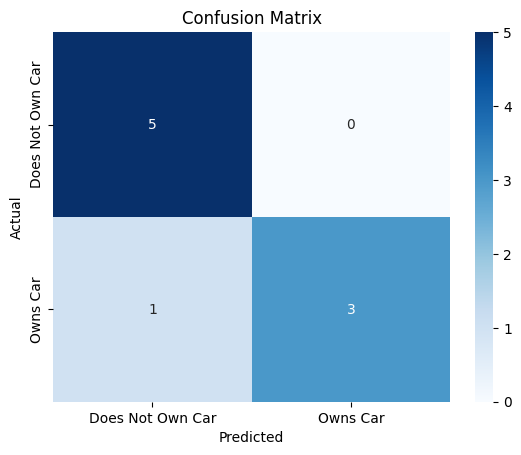

: 

In [ ]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
import seaborn as sns
import matplotlib.pyplot as plt
classes = ['Does Not Own Car', 'Owns Car']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
